In [1]:
import torch
import triton
import triton.language as tl
DEVICE = torch.device('cuda:0')

In [2]:
# autotune_config = [
#     triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE': 8}, num_stages=3, num_warps=8),
#     triton.Config({'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
#     triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
#     triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
#     triton.Config({'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
#     triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
#     triton.Config({'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 32,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=5, num_warps=2),
#     triton.Config({'BLOCK_SIZE_M': 32,  'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=5, num_warps=2),
# ]

autotune_config = [
     # NEW: T4-compatible large tiles
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=2, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=3, num_warps=4),

    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE': 8}, num_stages=3, num_warps=8),
    triton.Config({'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 32,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=5, num_warps=2),
    triton.Config({'BLOCK_SIZE_M': 32,  'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE': 8}, num_stages=5, num_warps=2),
]

@triton.autotune(configs=autotune_config, key=['M', 'N', 'K'])
@triton.jit
def _kernel_matmul(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_a_M, stride_a_K,
    stride_b_K, stride_b_N,
    stride_c_M, stride_c_N,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE: tl.constexpr,
):

  # --- STEP 1: CALCULATE THE TILE COORDINATES (SWIZZLE) ---
  # We convert the 1D PID into 2D coordinates (PID_M, PID_N).
  # Using GROUP_SIZE "snakes" the PIDs vertically through a strip.
  # This ensures multiple blocks reuse the same Matrix B data in the L2 Cache.

  PID = tl.program_id(axis=0)

  num_PID_along_M = tl.cdiv(M, BLOCK_SIZE_M) # 4 - How many tiles high
  num_PID_along_N = tl.cdiv(N, BLOCK_SIZE_N) # 4 - How many tiles wide


  # Swizzle Logic: (Standard boilerplate for Triton MatMul)
  num_PID_in_group = GROUP_SIZE * num_PID_along_N
  group_id = PID // num_PID_in_group
  first_PID_in_group_along_M = group_id * GROUP_SIZE
  group_size_adj = min(num_PID_along_M - first_PID_in_group_along_M, GROUP_SIZE)
  PID_M = first_PID_in_group_along_M + ((PID % num_PID_in_group) % group_size_adj)
  PID_N = (PID % num_PID_in_group) // group_size_adj

  # --- STEP 2: DEFINE MEMORY OFFSETS ---
  # offsets_M/N: The row/column indices this specific block owns.
  # offsets_K: The 'depth' indices we will iterate through.
  offsets_M = PID_M * BLOCK_SIZE_M  + tl.arange(0,BLOCK_SIZE_M)
  offsets_N = PID_N * BLOCK_SIZE_N  + tl.arange(0,BLOCK_SIZE_N)
  offsets_K = tl.arange(0,BLOCK_SIZE_K)

  # BROADCASTING: [:, None] (Column) + [None, :] (Row) = 2D Grid.
  # Address = Base_Pointer + (Row_Index * Row_Stride) + (Col_Index * Col_Stride)
  a_offsets = offsets_M[:,None] * stride_a_M + offsets_K[None,:] * stride_a_K
  b_offsets = offsets_K[:,None] * stride_b_K + offsets_N[None,:] * stride_b_N

  accumulator = tl.zeros((BLOCK_SIZE_M,BLOCK_SIZE_N),dtype=tl.float32)

  for k in range(0, tl.cdiv(K, BLOCK_SIZE_K)): #iterating along blocks along K
    mask = offsets_K < K - k * BLOCK_SIZE_K
    a = tl.load(a_ptr + a_offsets, mask=mask[None,:], other=0.0)
    b = tl.load(b_ptr + b_offsets, mask=mask[:,None], other=0.0)

    accumulator = tl.dot(a,b, acc=accumulator) # write directly to the accumulator matrix

    # ADVANCE: Shift pointers for the next 'k' step (Right in A, Down in B).
    a_offsets += BLOCK_SIZE_K * stride_a_K
    b_offsets += BLOCK_SIZE_K * stride_b_K

  accumulator = accumulator.to(tl.float16)
  c_offsets = offsets_M[:,None] * stride_c_M + offsets_N[None,:] * stride_c_N
  c_mask = (offsets_M[:,None]<M) & (offsets_N[None,:]<N)
  tl.store(c_ptr + c_offsets,accumulator, mask=c_mask)

In [3]:
def matmul(a, b):
  assert a.ndim == b.ndim == 2
  assert a.shape[1] == b.shape[0]

  (M, K), (_, N) = a.shape, b.shape

  c = torch.empty((M,N), device=DEVICE, dtype=torch.float16)

  grid = lambda meta: (
      triton.cdiv(M, meta['BLOCK_SIZE_M']) * triton.cdiv(N, meta['BLOCK_SIZE_N']),
  )

  _kernel_matmul[grid](
      a,b,c,
      M,N,K,
      a.stride(0), a.stride(1),
      b.stride(0), b.stride(1),
      c.stride(0), c.stride(1),
  )

  return c

In [4]:
def test_matmul_kernel(size:tuple, atol=1e-2, rtol=1e-3, device = DEVICE):
  torch.manual_seed(0)
  assert type(size)==tuple and len(size) == 2
  a = torch.randn(size, device = DEVICE, dtype=torch.float16)
  b = torch.randn(size, device = DEVICE, dtype=torch.float16)

  c_tri = matmul(a, b)
  c_ref = torch.matmul(a, b)

  torch.testing.assert_close(c_tri, c_ref, atol=atol, rtol=rtol)
  print("PASSED")


In [5]:
configs = [
    triton.testing.Benchmark(
        x_names = ["M", "N", "K"], # we can increase multiple dimensions simultaneously while benchmarking
        x_vals = [128 * i for i in range(2, 33)],
        line_arg = "provider",
        line_vals = ["torch", "triton"],
        line_names = ["PyTorch", "Triton"],
        styles = [("green", "-"), ("blue", "-")],
        ylabel = "TFLOPS",
        plot_name = "matmul-performance",
        args={},
    )
]
@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider):
    a = torch.randn((M, K), device=DEVICE, dtype=torch.float16)
    b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    quantiles = [0.5, 0.05, 0.95]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: matmul(a, b), quantiles=quantiles)
    perf = lambda ms: 3 * M * N * K * 1e-12 / (ms * 1e-3)
        # 3 = number of memory operations (2 read + 1 write)
        # M * N * K = number of elements per memory op
        # 1e-12 converts flops to Teraflops
        # 1e-3 converts milliseconds to seconds
    return perf(ms), perf(max_ms), perf(min_ms)


In [6]:
test_matmul_kernel(size=(512,512))

PASSED


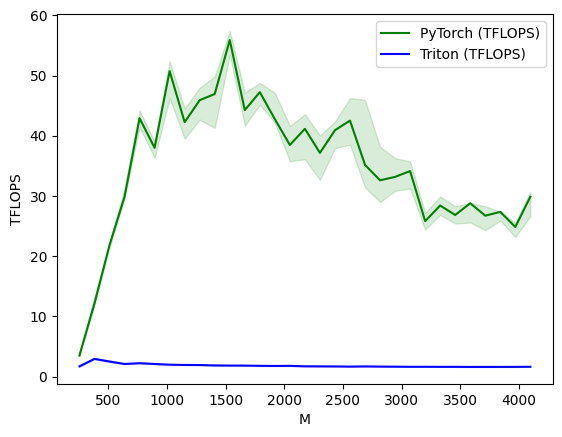

matmul-performance:
         M       N       K  PyTorch (TFLOPS)  Triton (TFLOPS)
0    256.0   256.0   256.0          3.510857         1.716164
1    384.0   384.0   384.0         12.175266         2.963112
2    512.0   512.0   512.0         21.845333         2.520615
3    640.0   640.0   640.0         29.861483         2.111522
4    768.0   768.0   768.0         42.917968         2.241316
5    896.0   896.0   896.0         38.003124         2.110888
6   1024.0  1024.0  1024.0         50.737549         1.994518
7   1152.0  1152.0  1152.0         42.254491         1.949115
8   1280.0  1280.0  1280.0         45.914993         1.937130
9   1408.0  1408.0  1408.0         46.930639         1.868153
10  1536.0  1536.0  1536.0         55.896448         1.849849
11  1664.0  1664.0  1664.0         44.261479         1.840825
12  1792.0  1792.0  1792.0         47.245148         1.804654
13  1920.0  1920.0  1920.0         42.768419         1.782975
14  2048.0  2048.0  2048.0         38.476177      

In [7]:
benchmark.run(show_plots=True, print_data=True)

In [8]:
print(_kernel_matmul.best_config)

BLOCK_SIZE_M: 64, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 32, GROUP_SIZE: 8, num_warps: 4, num_ctas: 1, num_stages: 4, maxnreg: None


In [9]:
import shutil, os
for path in ["/root/.triton/cache", os.path.expanduser("~/.triton/cache")]:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Deleted: {path}")

Deleted: /root/.triton/cache
